In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

from tensorflow import keras
from tensorflow.keras.preprocessing.image import load_img

In [ ]:
from PIL import Image, ImageFile
ImageFile.LOAD_TRUNCATED_IMAGES = True
import glob
image_list = []
i=0
for filepath in glob.glob('/https://www.kaggle.com/datasets/maysee/mushrooms-classification-common-genuss-images', recursive=True):
    mushroom_class = filepath.split("/")[-2]
    image_list.append((filepath, mushroom_class))

data = pd.DataFrame(image_list, columns = ['filepath', 'name'])
print('data shape: {}'.format(data.shape))


data shape: (0, 2)


In [ ]:
mushroom_classes = data['name'].unique()
mushroom_classes

array([], dtype=object)

In [ ]:
data.head()

,filepath,name


In [ ]:
import os

for root, dirs, files in os.walk("/kaggle/input"):
    print(root)


/kaggle/input


In [ ]:
from google.colab import files
files.upload()


Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"hemanth9398","key":"fa8ef05ba9e6ab137f631ef69d071d13"}'}

In [ ]:
import os

# Create Kaggle directory and move the JSON there
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Install the Kaggle library if it isn't already
!pip install -q kaggle


In [ ]:
# Download the dataset (will create a .zip file)
!kaggle datasets download -d maysee/mushrooms-classification-common-genuss-images


Dataset URL: https://www.kaggle.com/datasets/maysee/mushrooms-classification-common-genuss-images
License(s): copyright-authors
 99% 1.84G/1.85G [00:16<00:00, 256MB/s]
100% 1.85G/1.85G [00:16<00:00, 118MB/s]


In [ ]:
import zipfile

with zipfile.ZipFile("mushrooms-classification-common-genuss-images.zip", 'r') as zip_ref:
    zip_ref.extractall("mushroom_dataset")


In [ ]:
import os

for root, dirs, files in os.walk("mushroom_dataset"):
    print(root)


mushroom_dataset
mushroom_dataset/mushrooms
mushroom_dataset/mushrooms/Mushrooms
mushroom_dataset/mushrooms/Mushrooms/Agaricus
mushroom_dataset/mushrooms/Mushrooms/Russula
mushroom_dataset/mushrooms/Mushrooms/Amanita
mushroom_dataset/mushrooms/Mushrooms/Hygrocybe
mushroom_dataset/mushrooms/Mushrooms/Suillus
mushroom_dataset/mushrooms/Mushrooms/Cortinarius
mushroom_dataset/mushrooms/Mushrooms/Boletus
mushroom_dataset/mushrooms/Mushrooms/Entoloma
mushroom_dataset/mushrooms/Mushrooms/Lactarius
mushroom_dataset/Mushrooms
mushroom_dataset/Mushrooms/Agaricus
mushroom_dataset/Mushrooms/Russula
mushroom_dataset/Mushrooms/Amanita
mushroom_dataset/Mushrooms/Hygrocybe
mushroom_dataset/Mushrooms/Suillus
mushroom_dataset/Mushrooms/Cortinarius
mushroom_dataset/Mushrooms/Boletus
mushroom_dataset/Mushrooms/Entoloma
mushroom_dataset/Mushrooms/Lactarius


In [ ]:
from PIL import Image, ImageFile
import pandas as pd
import glob

ImageFile.LOAD_TRUNCATED_IMAGES = True

image_list = []
image_dir = "mushroom_dataset/mushrooms/Mushrooms"

for filepath in glob.glob(f'{image_dir}/*/*.jpg', recursive=True):
    mushroom_class = filepath.split("/")[-2]
    image_list.append((filepath, mushroom_class))

data = pd.DataFrame(image_list, columns=['filepath', 'name'])
print('data shape:', data.shape)
data


data shape: (6714, 2)


,filepath,name
0,mushroom_dataset/mushrooms/Mushrooms/Agaricus/...,Agaricus
1,mushroom_dataset/mushrooms/Mushrooms/Agaricus/...,Agaricus
2,mushroom_dataset/mushrooms/Mushrooms/Agaricus/...,Agaricus
3,mushroom_dataset/mushrooms/Mushrooms/Agaricus/...,Agaricus
4,mushroom_dataset/mushrooms/Mushrooms/Agaricus/...,Agaricus
...,...,...
6709,mushroom_dataset/mushrooms/Mushrooms/Lactarius...,Lactarius
6710,mushroom_dataset/mushrooms/Mushrooms/Lactarius...,Lactarius
6711,mushroom_dataset/mushrooms/Mushrooms/Lactarius...,Lactarius
6712,mushroom_dataset/mushrooms/Mushrooms/Lactarius...,Lactarius


/tmp/ipython-input-8-3738136338.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=data, x='name', order=data['name'].value_counts().index, palette="Set2")
/tmp/ipython-input-8-3738136338.py:14: UserWarning: Glyph 127812 (\N{MUSHROOM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127812 (\N{MUSHROOM}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


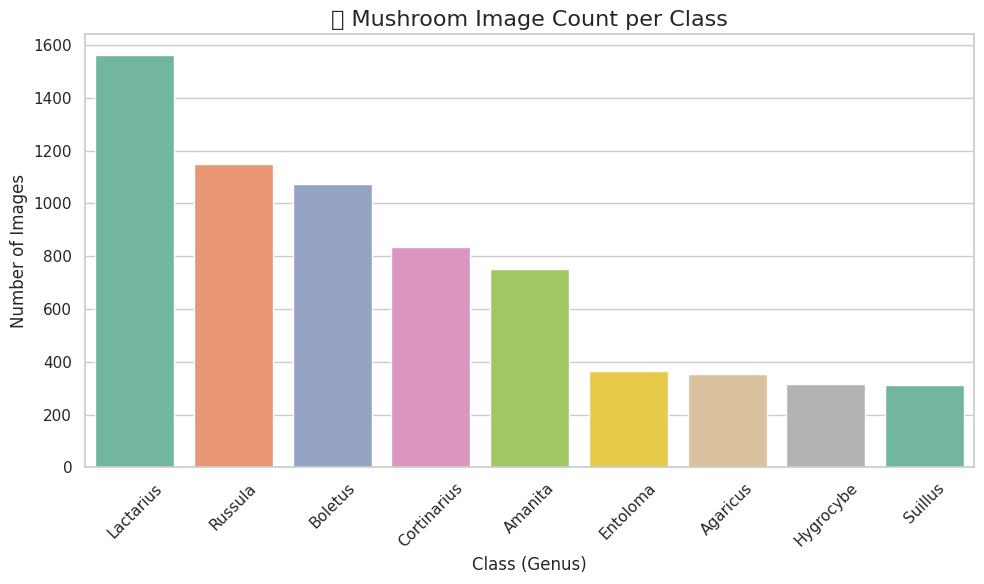

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the style (optional but makes it sexy)
sns.set(style="whitegrid")

# Plot the class distribution
plt.figure(figsize=(10, 6))
ax = sns.countplot(data=data, x='name', order=data['name'].value_counts().index, palette="Set2")
plt.title("🍄 Mushroom Image Count per Class", fontsize=16)
plt.xlabel("Class (Genus)", fontsize=12)
plt.ylabel("Number of Images", fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [ ]:
data['name'].value_counts()


,count
name,
Lactarius,1563
Russula,1148
Boletus,1073
Cortinarius,836
Amanita,750
Entoloma,364
Agaricus,353
Hygrocybe,316
Suillus,311


In [ ]:
%pwd

'/content'

In [ ]:
import os
import random
from PIL import Image
from torchvision import transforms
from tqdm import tqdm

# Set base directory and target count
base_dir = '/content/mushroom_dataset/mushrooms/Mushrooms'
target_count = 1563

# Define image augmentations
augment = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(30),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2),
    transforms.RandomResizedCrop(size=(224, 224), scale=(0.8, 1.0)),
])

# Loop through each class folder
for class_name in os.listdir(base_dir):
    class_path = os.path.join(base_dir, class_name)
    if not os.path.isdir(class_path):
        continue

    files = [f for f in os.listdir(class_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    current_count = len(files)

    print(f"📂 {class_name}: {current_count} images")

    if current_count >= target_count:
        continue  # Skip already balanced classes

    print(f"🔁 Augmenting {class_name} to reach {target_count} images...")

    # Augment until we reach the target
    while len(files) < target_count:
        img_name = random.choice(files)
        img_path = os.path.join(class_path, img_name)
        try:
            img = Image.open(img_path).convert("RGB")
            augmented = augment(img)
            save_name = f"aug_{len(files)}_{img_name}"
            save_path = os.path.join(class_path, save_name)
            augmented.save(save_path)
            files.append(save_name)
        except Exception as e:
            print(f"⚠️ Failed to augment {img_name}: {e}")


📂 Agaricus: 353 images
🔁 Augmenting Agaricus to reach 1563 images...
📂 Russula: 1148 images
🔁 Augmenting Russula to reach 1563 images...
📂 Amanita: 750 images
🔁 Augmenting Amanita to reach 1563 images...
📂 Hygrocybe: 316 images
🔁 Augmenting Hygrocybe to reach 1563 images...
📂 Suillus: 311 images
🔁 Augmenting Suillus to reach 1563 images...
📂 Cortinarius: 836 images
🔁 Augmenting Cortinarius to reach 1563 images...
📂 Boletus: 1073 images
🔁 Augmenting Boletus to reach 1563 images...
📂 Entoloma: 364 images
🔁 Augmenting Entoloma to reach 1563 images...
📂 Lactarius: 1563 images


In [ ]:
import os
import pandas as pd

base_dir = '/content/mushroom_dataset/mushrooms/Mushrooms'
image_list = []

# Walk through each class folder and collect image paths + class names
for class_name in os.listdir(base_dir):
    class_path = os.path.join(base_dir, class_name)
    if not os.path.isdir(class_path):
        continue
    for file in os.listdir(class_path):
        if file.lower().endswith(('.jpg', '.jpeg', '.png')):
            image_list.append((os.path.join(class_path, file), class_name))

# Build a DataFrame
data = pd.DataFrame(image_list, columns=['filepath', 'name'])

# Print counts
print(data['name'].value_counts())


name
Agaricus       1563
Russula        1563
Amanita        1563
Hygrocybe      1563
Suillus        1563
Cortinarius    1563
Boletus        1563
Entoloma       1563
Lactarius      1563
Name: count, dtype: int64


/tmp/ipython-input-13-939393750.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=data, x='name', order=data['name'].value_counts().index, palette="Set3")
/tmp/ipython-input-13-939393750.py:13: UserWarning: Glyph 127812 (\N{MUSHROOM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127812 (\N{MUSHROOM}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


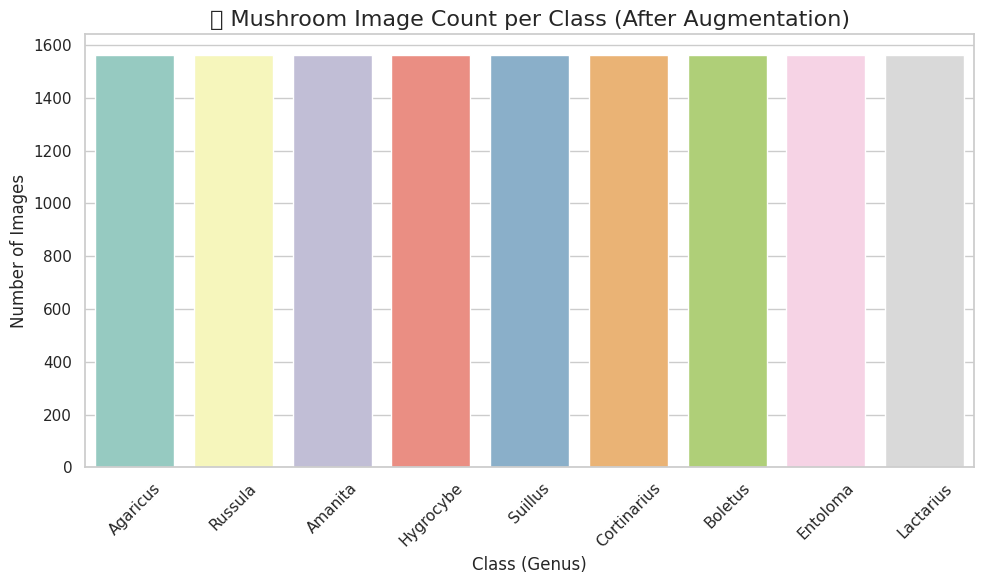

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="whitegrid")

plt.figure(figsize=(10, 6))
ax = sns.countplot(data=data, x='name', order=data['name'].value_counts().index, palette="Set3")

plt.title("🍄 Mushroom Image Count per Class (After Augmentation)", fontsize=16)
plt.xlabel("Class (Genus)", fontsize=12)
plt.ylabel("Number of Images", fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [ ]:
import os
import pandas as pd

base_dir = '/content/mushroom_dataset/mushrooms/Mushrooms'
image_list = []

for class_name in os.listdir(base_dir):
    class_path = os.path.join(base_dir, class_name)
    if not os.path.isdir(class_path):
        continue
    for file in os.listdir(class_path):
        if file.lower().endswith(('.jpg', '.jpeg', '.png')):
            image_list.append((os.path.join(class_path, file), class_name))

data = pd.DataFrame(image_list, columns=['filepath', 'label'])


In [ ]:
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical

# Label encode class names
label_encoder = LabelEncoder()
data['label_encoded'] = label_encoder.fit_transform(data['label'])

# One-hot encode
data['label_onehot'] = list(to_categorical(data['label_encoded']))


In [ ]:
from sklearn.model_selection import train_test_split

train_df, val_df = train_test_split(data, test_size=0.2, stratify=data['label'], random_state=42)


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Image augmentations for training
train_datagen = ImageDataGenerator(
    rescale=1./255,
    horizontal_flip=True,
    rotation_range=15,
    zoom_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1
)

# Just rescaling for validation
val_datagen = ImageDataGenerator(rescale=1./255)

# Define generators
train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col='filepath',
    y_col='label_onehot',
    target_size=(256, 256),
    batch_size=32,
    class_mode='raw',  # since we already one-hot encoded
    shuffle=True
)

val_generator = val_datagen.flow_from_dataframe(
    dataframe=val_df,
    x_col='filepath',
    y_col='label_onehot',
    target_size=(256, 256),
    batch_size=32,
    class_mode='raw',
    shuffle=False
)


Found 11253 validated image filenames.
Found 2814 validated image filenames.


In [ ]:
from tensorflow.keras.applications import VGG16
from tensorflow import keras
from tensorflow.keras.layers import GlobalAveragePooling2D, Dropout, Dense

def create_VGG16_model(learning_rate=1e-4):
    base_model = VGG16(weights='imagenet', include_top=False, input_shape=(256, 256, 3))
    base_model.trainable = True  # LET IT LEARN!

    inputs = keras.Input(shape=(256, 256, 3))
    x = base_model(inputs, training=True)
    x = GlobalAveragePooling2D()(x)
    x = Dropout(0.5)(x)  # helps generalize
    outputs = Dense(9, activation='softmax')(x)  # use softmax here

    model = keras.Model(inputs, outputs)

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss=keras.losses.CategoricalCrossentropy(from_logits=False),  # not using logits now
        metrics=['accuracy']
    )

    return model


In [ ]:
model = create_VGG16_model(learning_rate=0.0001)


58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


In [ ]:
import numpy as np
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical

# Encode labels
label_encoder = LabelEncoder()
data['label_encoded'] = label_encoder.fit_transform(data['label'])

# Proper one-hot as np arrays (not lists)
onehot = to_categorical(data['label_encoded'])
data['label_onehot'] = list(onehot)  # each entry is now np.array, not list


In [ ]:
type(data['label_onehot'].iloc[0])  # should return <class 'numpy.ndarray'>


numpy.ndarray

In [ ]:
from sklearn.model_selection import train_test_split

train_df, val_df = train_test_split(data, test_size=0.2, stratify=data['label'], random_state=42)


In [ ]:
train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col='filepath',
    y_col='label_onehot',
    target_size=(256, 256),
    batch_size=32,
    class_mode='raw',
    shuffle=True
)

val_generator = val_datagen.flow_from_dataframe(
    dataframe=val_df,
    x_col='filepath',
    y_col='label_onehot',
    target_size=(256, 256),
    batch_size=32,
    class_mode='raw',
    shuffle=False
)


Found 11253 validated image filenames.
Found 2814 validated image filenames.


In [ ]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
data['label_encoded'] = label_encoder.fit_transform(data['label'])

# One-hot encode and concat to main DataFrame
onehot_df = pd.get_dummies(data['label_encoded'], prefix='class')
data = pd.concat([data, onehot_df], axis=1)


In [ ]:
train_df, val_df = train_test_split(data, test_size=0.2, stratify=data['label'], random_state=42)


In [ ]:
onehot_columns = [col for col in data.columns if col.startswith('class_')]

train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col='filepath',
    y_col=onehot_columns,
    target_size=(256, 256),
    batch_size=32,
    class_mode='raw',  # still 'raw' because now it's actual columns
    shuffle=True
)

val_generator = val_datagen.flow_from_dataframe(
    dataframe=val_df,
    x_col='filepath',
    y_col=onehot_columns,
    target_size=(256, 256),
    batch_size=32,
    class_mode='raw',
    shuffle=False
)


Found 11253 validated image filenames.
Found 2814 validated image filenames.


In [ ]:
model = create_VGG16_model(learning_rate=0.0001)

history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10
)


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 0s 668ms/step - accuracy: 0.1175 - loss: 2.3503

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


352/352 ━━━━━━━━━━━━━━━━━━━━ 292s 777ms/step - accuracy: 0.1175 - loss: 2.3500 - val_accuracy: 0.1439 - val_loss: 2.1761
Epoch 2/10
236/352 ━━━━━━━━━━━━━━━━━━━━ 1:12 624ms/step - accuracy: 0.1665 - loss: 2.1619

KeyboardInterrupt: 

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

checkpoint = ModelCheckpoint('best_model.h5', monitor='val_accuracy', save_best_only=True)

model = create_VGG16_model(learning_rate=1e-5)

history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=30,
    callbacks=[early_stop, checkpoint]
)


Epoch 1/30
352/352 ━━━━━━━━━━━━━━━━━━━━ 0s 905ms/step - accuracy: 0.2121 - loss: 2.1341

352/352 ━━━━━━━━━━━━━━━━━━━━ 469s 1s/step - accuracy: 0.2124 - loss: 2.1333 - val_accuracy: 0.5160 - val_loss: 1.4197
Epoch 2/30
352/352 ━━━━━━━━━━━━━━━━━━━━ 0s 808ms/step - accuracy: 0.5023 - loss: 1.3929

352/352 ━━━━━━━━━━━━━━━━━━━━ 334s 868ms/step - accuracy: 0.5023 - loss: 1.3927 - val_accuracy: 0.6407 - val_loss: 1.0352
Epoch 3/30
352/352 ━━━━━━━━━━━━━━━━━━━━ 0s 793ms/step - accuracy: 0.6181 - loss: 1.1067

352/352 ━━━━━━━━━━━━━━━━━━━━ 301s 853ms/step - accuracy: 0.6182 - loss: 1.1066 - val_accuracy: 0.6485 - val_loss: 0.9974
Epoch 4/30
214/352 ━━━━━━━━━━━━━━━━━━━━ 1:50 800ms/step - accuracy: 0.6895 - loss: 0.9251

/usr/local/lib/python3.11/dist-packages/keras/src/legacy/preprocessing/image.py:1880: DeprecationWarning: Please import `affine_transform` from the `scipy.ndimage` namespace; the `scipy.ndimage.interpolation` namespace is deprecated and will be removed in SciPy 2.0.0.
  scipy.ndimage.interpolation.affine_transform(


...

352/352 ━━━━━━━━━━━━━━━━━━━━ 301s 854ms/step - accuracy: 0.9544 - loss: 0.1398 - val_accuracy: 0.9375 - val_loss: 0.2186
Epoch 23/30
352/352 ━━━━━━━━━━━━━━━━━━━━ 299s 849ms/step - accuracy: 0.9520 - loss: 0.1398 - val_accuracy: 0.9165 - val_loss: 0.2845
Epoch 24/30
352/352 ━━━━━━━━━━━━━━━━━━━━ 299s 848ms/step - accuracy: 0.9577 - loss: 0.1275 - val_accuracy: 0.9328 - val_loss: 0.2324
Epoch 25/30
256/352 ━━━━━━━━━━━━━━━━━━━━ 1:15 789ms/step - accuracy: 0.9581 - loss: 0.1292

/usr/local/lib/python3.11/dist-packages/keras/src/legacy/preprocessing/image.py:1880: DeprecationWarning: Please import `affine_transform` from the `scipy.ndimage` namespace; the `scipy.ndimage.interpolation` namespace is deprecated and will be removed in SciPy 2.0.0.
  scipy.ndimage.interpolation.affine_transform(


352/352 ━━━━━━━━━━━━━━━━━━━━ 321s 845ms/step - accuracy: 0.9582 - loss: 0.1287 - val_accuracy: 0.9289 - val_loss: 0.2783
Epoch 26/30
352/352 ━━━━━━━━━━━━━━━━━━━━ 320s 908ms/step - accuracy: 0.9594 - loss: 0.1239 - val_accuracy: 0.9364 - val_loss: 0.2078
Epoch 27/30
352/352 ━━━━━━━━━━━━━━━━━━━━ 302s 856ms/step - accuracy: 0.9671 - loss: 0.1034 - val_accuracy: 0.9364 - val_loss: 0.2135
Epoch 28/30
352/352 ━━━━━━━━━━━━━━━━━━━━ 0s 793ms/step - accuracy: 0.9640 - loss: 0.1045

352/352 ━━━━━━━━━━━━━━━━━━━━ 300s 852ms/step - accuracy: 0.9641 - loss: 0.1045 - val_accuracy: 0.9421 - val_loss: 0.2113
Epoch 29/30
352/352 ━━━━━━━━━━━━━━━━━━━━ 303s 859ms/step - accuracy: 0.9693 - loss: 0.0954 - val_accuracy: 0.9392 - val_loss: 0.2196
Epoch 30/30
352/352 ━━━━━━━━━━━━━━━━━━━━ 0s 803ms/step - accuracy: 0.9691 - loss: 0.0901

352/352 ━━━━━━━━━━━━━━━━━━━━ 304s 863ms/step - accuracy: 0.9691 - loss: 0.0901 - val_accuracy: 0.9474 - val_loss: 0.1957


In [ ]:
model.save("mushroom_classifier.keras")


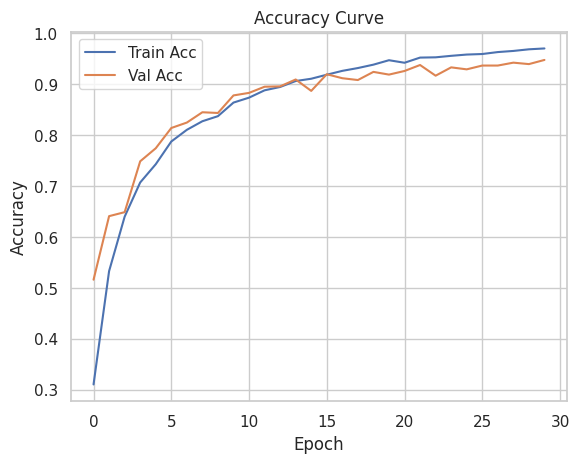

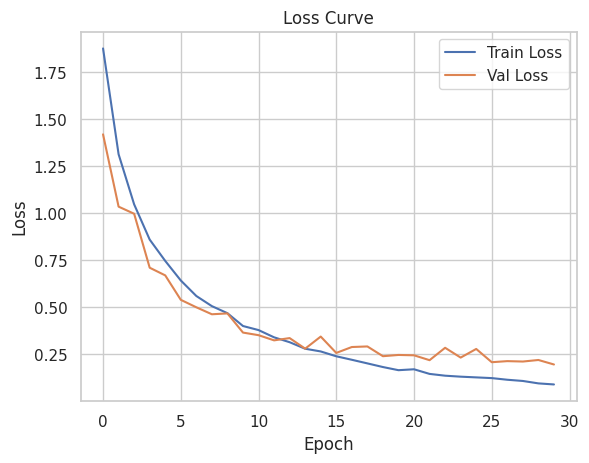

In [ ]:
import matplotlib.pyplot as plt

# Accuracy
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('Accuracy Curve')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

# Loss
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
import numpy as np

# Get predictions (probabilities)
pred_probs = model.predict(val_generator)
# Get predicted class indices
pred_classes = np.argmax(pred_probs, axis=1)

# True class indices
true_classes = np.argmax(val_generator.labels, axis=1)  # if you're using one-hot


88/88 ━━━━━━━━━━━━━━━━━━━━ 22s 240ms/step


              precision    recall  f1-score   support

    Agaricus       0.96      0.94      0.95       313
     Amanita       0.93      0.95      0.94       312
     Boletus       0.97      0.97      0.97       313
 Cortinarius       0.94      0.94      0.94       313
    Entoloma       0.96      0.97      0.96       313
   Hygrocybe       1.00      0.99      1.00       312
   Lactarius       0.90      0.91      0.90       313
     Russula       0.90      0.91      0.91       312
     Suillus       0.96      0.94      0.95       313

    accuracy                           0.95      2814
   macro avg       0.95      0.95      0.95      2814
weighted avg       0.95      0.95      0.95      2814



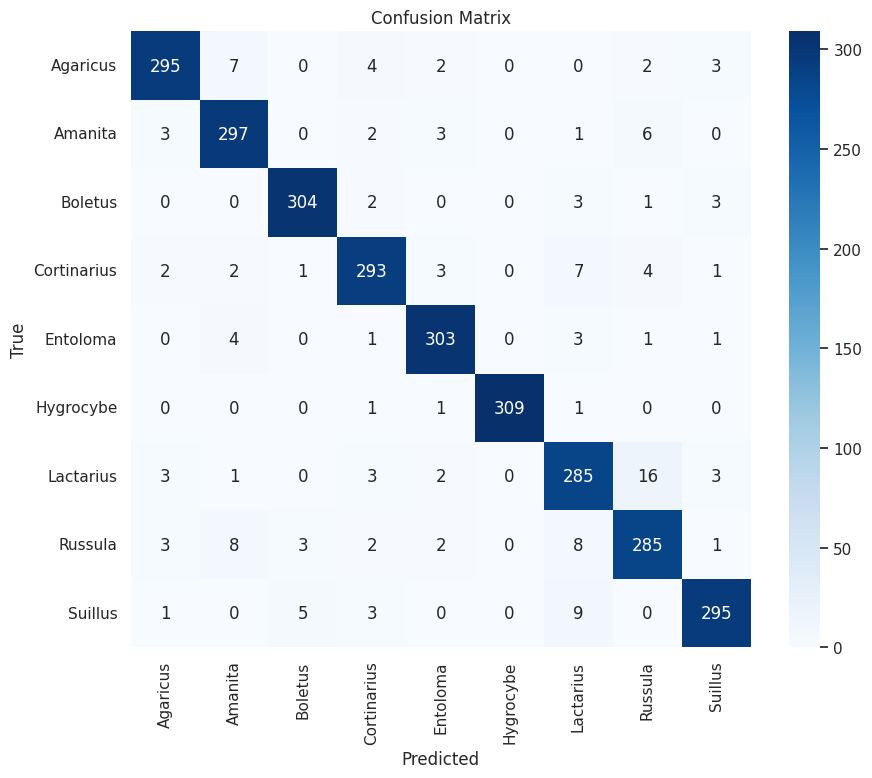

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Print classification report
print(classification_report(true_classes, pred_classes, target_names=label_encoder.classes_))

# Plot confusion matrix
cm = confusion_matrix(true_classes, pred_classes)

plt.figure(figsize=(7, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()


In [ ]:
from tensorflow.keras.preprocessing.image import load_img, img_to_array

# Load and preprocess image
img_path = "/content/mushroom_dataset/mushrooms/Mushrooms/Entoloma/000_pIBnrKk4HoA.jpg"
img = load_img(img_path, target_size=(256, 256))
img_array = img_to_array(img) / 255.0
img_array = np.expand_dims(img_array, axis=0)

# Predict
pred = model.predict(img_array)
pred_class = np.argmax(pred)
print("Predicted class:", label_encoder.inverse_transform([pred_class])[0])


1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
Predicted class: Entoloma


In [ ]:
from sklearn.model_selection import train_test_split

# First, split into train+temp
train_df, temp_df = train_test_split(data, test_size=0.4, stratify=data['label'], random_state=42)

# Then split temp into validation + test
val_df, test_df = train_test_split(temp_df, test_size=0.5, stratify=temp_df['label'], random_state=42)


In [ ]:
onehot_columns = [col for col in data.columns if col.startswith('class_')]

train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col='filepath',
    y_col=onehot_columns,
    target_size=(256, 256),
    batch_size=32,
    class_mode='raw',
    shuffle=True
)

val_generator = val_datagen.flow_from_dataframe(
    dataframe=val_df,
    x_col='filepath',
    y_col=onehot_columns,
    target_size=(256, 256),
    batch_size=32,
    class_mode='raw',
    shuffle=False
)

test_generator = val_datagen.flow_from_dataframe(
    dataframe=test_df,
    x_col='filepath',
    y_col=onehot_columns,
    target_size=(256, 256),
    batch_size=32,
    class_mode='raw',
    shuffle=False
)


Found 8440 validated image filenames.
Found 2813 validated image filenames.
Found 2814 validated image filenames.


In [ ]:
# Evaluate final model on true test set
test_loss, test_acc = model.evaluate(test_generator)
print(f"Test Accuracy: {test_acc:.4f}")


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


88/88 ━━━━━━━━━━━━━━━━━━━━ 21s 235ms/step - accuracy: 0.9662 - loss: 0.1241
Test Accuracy: 0.9680


88/88 ━━━━━━━━━━━━━━━━━━━━ 22s 253ms/step
              precision    recall  f1-score   support

    Agaricus       0.98      0.96      0.97       312
     Amanita       0.96      0.97      0.96       312
     Boletus       0.97      0.98      0.98       313
 Cortinarius       0.97      0.96      0.96       313
    Entoloma       0.97      0.98      0.98       313
   Hygrocybe       1.00      0.99      1.00       313
   Lactarius       0.95      0.95      0.95       313
     Russula       0.94      0.96      0.95       312
     Suillus       0.97      0.97      0.97       313

    accuracy                           0.97      2814
   macro avg       0.97      0.97      0.97      2814
weighted avg       0.97      0.97      0.97      2814



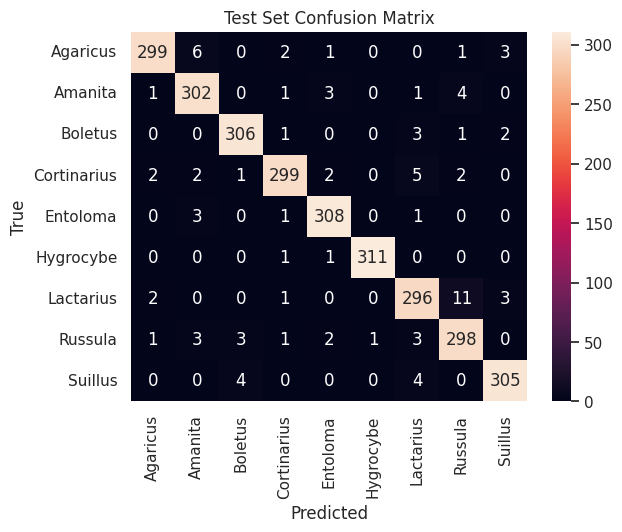

In [ ]:
pred_probs = model.predict(test_generator)
pred_classes = np.argmax(pred_probs, axis=1)
true_classes = np.argmax(test_generator.labels, axis=1)

print(classification_report(true_classes, pred_classes, target_names=label_encoder.classes_))

cm = confusion_matrix(true_classes, pred_classes)
sns.heatmap(cm, annot=True, fmt='d', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Test Set Confusion Matrix")
plt.show()
